## Experiment 1: Store-specific Random Forest with extra features

In [2]:
# ============================================================
# EXPERIMENT 1:
# Store-Specific Random Forest with Extra Features
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Load final model-ready dataset
# ------------------------------------------------------------

DATA_DIR = Path("top_3_data")

df = pd.read_csv(DATA_DIR / "top3_model_ready_training_data.csv")

df["visit_date"] = pd.to_datetime(df["visit_date"])
df = df.sort_values(["air_store_id", "visit_date"]).reset_index(drop=True)

print("Original dataset shape:", df.shape)
print("Restaurants:", df["air_store_id"].nunique())
print(df["air_store_id"].unique())

Original dataset shape: (1345, 27)
Restaurants: 3
['air_36bcf77d3382d36e' 'air_5c817ef28f236bdf' 'air_a083834e7ffe187e']


In [3]:
# ------------------------------------------------------------
# 2. Add extra historical visitor features
# ------------------------------------------------------------

df = df.sort_values(["air_store_id", "visit_date"]).reset_index(drop=True)

# Extra lag features
extra_lags = [2, 3, 21, 35]

for lag in extra_lags:
    df[f"visitors_lag_{lag}"] = (
        df.groupby("air_store_id")["visitors"].shift(lag)
    )

# Rolling standard deviation features
# These help the model understand how unstable/variable demand has been recently
for window in [7, 14, 28]:
    df[f"visitors_rolling_{window}_std"] = (
        df.groupby("air_store_id")["visitors"]
        .transform(lambda x: x.shift(1).rolling(window=window).std())
    )

# Same weekday expanding average
# Example: to predict a Saturday, use average of previous Saturdays
df["same_weekday_avg"] = (
    df.groupby(["air_store_id", "day_of_week_num"])["visitors"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

# List of new features
extra_feature_cols = [
    "visitors_lag_2",
    "visitors_lag_3",
    "visitors_lag_21",
    "visitors_lag_35",
    "visitors_rolling_7_std",
    "visitors_rolling_14_std",
    "visitors_rolling_28_std",
    "same_weekday_avg"
]

# Drop rows where new historical features are missing
# These missing values only occur at the beginning of each restaurant time series
df = df.dropna(subset=extra_feature_cols).reset_index(drop=True)

print("Dataset shape after adding extra features:", df.shape)

df.head()

Dataset shape after adding extra features: (1240, 35)


,air_store_id,visit_date,visitors,day_of_week,holiday_flg,month,day,year,week_of_year,day_of_week_num,...,visitors_rolling_14_mean,visitors_rolling_28_mean,visitors_lag_2,visitors_lag_3,visitors_lag_21,visitors_lag_35,visitors_rolling_7_std,visitors_rolling_14_std,visitors_rolling_28_std,same_weekday_avg
0,air_36bcf77d3382d36e,2016-03-05,60,Saturday,0,3,5,2016,9,5,...,29.000000,30.857143,17.0,14.0,43.0,45.0,19.364917,16.347195,14.104673,45.8
1,air_36bcf77d3382d36e,2016-03-06,66,Sunday,0,3,6,2016,9,6,...,29.642857,31.500000,30.0,17.0,55.0,56.0,21.437617,17.420621,15.012341,50.6
2,air_36bcf77d3382d36e,2016-03-07,20,Monday,0,3,7,2016,10,0,...,32.071429,32.357143,60.0,30.0,31.0,17.0,20.911378,19.959437,16.266790,21.0
3,air_36bcf77d3382d36e,2016-03-08,24,Tuesday,0,3,8,2016,10,1,...,32.642857,32.321429,66.0,60.0,17.0,9.0,21.263651,19.448580,16.293724,18.8
4,air_36bcf77d3382d36e,2016-03-09,19,Wednesday,0,3,9,2016,10,2,...,32.857143,32.321429,20.0,66.0,21.0,16.0,21.189620,19.326575,16.293724,19.4


In [4]:
# ------------------------------------------------------------
# 3. Define target and feature columns
# ------------------------------------------------------------

target = "visitors"

features = [
    # Calendar features
    "holiday_flg",
    "month",
    "day",
    "year",
    "week_of_year",
    "day_of_week_num",
    "is_weekend",

    # Location features
    "latitude",
    "longitude",

    # Reservation features
    "reserved_visitors_sum",
    "reservation_count",
    "reserved_visitors_mean",
    "avg_reserve_lead_days",
    "has_reservation_data",

    # Original historical visitor features
    "visitors_lag_1",
    "visitors_lag_7",
    "visitors_lag_14",
    "visitors_lag_28",
    "visitors_rolling_7_mean",
    "visitors_rolling_14_mean",
    "visitors_rolling_28_mean",

    # Extra historical visitor features
    "visitors_lag_2",
    "visitors_lag_3",
    "visitors_lag_21",
    "visitors_lag_35",
    "visitors_rolling_7_std",
    "visitors_rolling_14_std",
    "visitors_rolling_28_std",
    "same_weekday_avg",

    # Restaurant information
    "air_genre_name",
    "air_area_name"
]

# Keep only features that exist in the dataframe
features = [col for col in features if col in df.columns]

print("Number of features used:", len(features))
print(features)

Number of features used: 31
['holiday_flg', 'month', 'day', 'year', 'week_of_year', 'day_of_week_num', 'is_weekend', 'latitude', 'longitude', 'reserved_visitors_sum', 'reservation_count', 'reserved_visitors_mean', 'avg_reserve_lead_days', 'has_reservation_data', 'visitors_lag_1', 'visitors_lag_7', 'visitors_lag_14', 'visitors_lag_28', 'visitors_rolling_7_mean', 'visitors_rolling_14_mean', 'visitors_rolling_28_mean', 'visitors_lag_2', 'visitors_lag_3', 'visitors_lag_21', 'visitors_lag_35', 'visitors_rolling_7_std', 'visitors_rolling_14_std', 'visitors_rolling_28_std', 'same_weekday_avg', 'air_genre_name', 'air_area_name']


In [5]:
# ------------------------------------------------------------
# 4. Store-specific Random Forest training
# ------------------------------------------------------------

TEST_DAYS = 39

restaurant_models = {}
all_results = []
restaurant_metrics = []
feature_importances_all = []

for restaurant_id in df["air_store_id"].unique():

    print("\n========================================")
    print("Training model for:", restaurant_id)
    print("========================================")

    # Select one restaurant
    restaurant_df = df[df["air_store_id"] == restaurant_id].copy()
    restaurant_df = restaurant_df.sort_values("visit_date")

    # Time-based split: last 39 rows for testing
    train_df = restaurant_df.iloc[:-TEST_DAYS]
    test_df = restaurant_df.iloc[-TEST_DAYS:]

    print("Training rows:", len(train_df))
    print("Testing rows:", len(test_df))
    print("Test date range:", test_df["visit_date"].min(), "to", test_df["visit_date"].max())

    # Split X and y
    X_train = train_df[features]
    y_train = train_df[target]

    X_test = test_df[features]
    y_test = test_df[target]

    # One-hot encode categorical features
    X_train_encoded = pd.get_dummies(X_train)
    X_test_encoded = pd.get_dummies(X_test)

    # Align train and test columns
    X_train_encoded, X_test_encoded = X_train_encoded.align(
        X_test_encoded,
        join="left",
        axis=1,
        fill_value=0
    )

    # Random Forest model
    model = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        max_depth=14,
        min_samples_leaf=2,
        max_features="sqrt"
    )

    # Train
    model.fit(X_train_encoded, y_train)

    # Predict
    predictions = model.predict(X_test_encoded)
    predictions = np.maximum(predictions, 0)

    # Save model
    restaurant_models[restaurant_id] = model

    # Results table
    temp_results = test_df[["air_store_id", "visit_date", "visitors"]].copy()
    temp_results["predicted_visitors"] = predictions
    temp_results["predicted_visitors_rounded"] = np.round(predictions).astype(int)
    temp_results["absolute_error"] = abs(
        temp_results["visitors"] - temp_results["predicted_visitors"]
    )

    all_results.append(temp_results)

    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    rmsle = np.sqrt(mean_squared_log_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    mean_actual = y_test.mean()
    practical_accuracy = (1 - (mae / mean_actual)) * 100

    restaurant_metrics.append({
        "air_store_id": restaurant_id,
        "training_rows": len(train_df),
        "testing_rows": len(test_df),
        "mean_actual_visitors": mean_actual,
        "mae": mae,
        "rmse": rmse,
        "rmsle": rmsle,
        "r2_score": r2,
        "practical_accuracy_percent": practical_accuracy
    })

    # Feature importance for this restaurant
    feature_importance = pd.DataFrame({
        "air_store_id": restaurant_id,
        "feature": X_train_encoded.columns,
        "importance": model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    feature_importances_all.append(feature_importance)

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Practical Accuracy: {practical_accuracy:.2f}%")


Training model for: air_36bcf77d3382d36e
Training rows: 374
Testing rows: 39
Test date range: 2017-03-15 00:00:00 to 2017-04-22 00:00:00
MAE: 7.78
RMSE: 10.00
RMSLE: 0.3158
R² Score: 0.6516
Practical Accuracy: 74.34%

Training model for: air_5c817ef28f236bdf
Training rows: 375
Testing rows: 39
Test date range: 2017-03-15 00:00:00 to 2017-04-22 00:00:00
MAE: 12.46
RMSE: 14.84
RMSLE: 0.4451
R² Score: 0.6031
Practical Accuracy: 72.25%

Training model for: air_a083834e7ffe187e
Training rows: 374
Testing rows: 39
Test date range: 2017-03-14 00:00:00 to 2017-04-22 00:00:00
MAE: 5.46
RMSE: 7.37
RMSLE: 0.4833
R² Score: 0.6973
Practical Accuracy: 77.35%


In [6]:
# ------------------------------------------------------------
# 5. Overall evaluation
# ------------------------------------------------------------

store_specific_extra_results = pd.concat(all_results).reset_index(drop=True)
restaurant_metrics_extra_df = pd.DataFrame(restaurant_metrics)
feature_importance_extra_df = pd.concat(feature_importances_all).reset_index(drop=True)

y_true = store_specific_extra_results["visitors"]
y_pred = store_specific_extra_results["predicted_visitors"]

overall_mae = mean_absolute_error(y_true, y_pred)
overall_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
overall_rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
overall_r2 = r2_score(y_true, y_pred)

overall_mean_actual = y_true.mean()
overall_practical_accuracy = (1 - (overall_mae / overall_mean_actual)) * 100

print("STORE-SPECIFIC RANDOM FOREST WITH EXTRA FEATURES")
print("------------------------------------------------")
print(f"MAE  - Average error in visitors: {overall_mae:.2f}")
print(f"RMSE - Root mean squared error: {overall_rmse:.2f}")
print(f"RMSLE - Log error score: {overall_rmsle:.4f}")
print(f"R² Score: {overall_r2:.4f}")
print(f"Mean actual visitors: {overall_mean_actual:.2f}")
print(f"Practical accuracy estimate: {overall_practical_accuracy:.2f}%")

STORE-SPECIFIC RANDOM FOREST WITH EXTRA FEATURES
------------------------------------------------
MAE  - Average error in visitors: 8.57
RMSE - Root mean squared error: 11.18
RMSLE - Log error score: 0.4209
R² Score: 0.7003
Mean actual visitors: 33.11
Practical accuracy estimate: 74.13%


In [7]:
restaurant_metrics_extra_df

,air_store_id,training_rows,testing_rows,mean_actual_visitors,mae,rmse,rmsle,r2_score,practical_accuracy_percent
0,air_36bcf77d3382d36e,374,39,30.307692,7.775723,10.003650,0.315831,0.651603,74.344062
1,air_5c817ef28f236bdf,375,39,44.923077,12.464132,14.844520,0.445115,0.603061,72.254500
2,air_a083834e7ffe187e,374,39,24.102564,5.458928,7.372278,0.483255,0.697259,77.351257


In [8]:
store_specific_extra_results.to_csv(
    DATA_DIR / "experiment1_store_specific_rf_extra_daily_results.csv",
    index=False
)

restaurant_metrics_extra_df.to_csv(
    DATA_DIR / "experiment1_store_specific_rf_extra_metrics.csv",
    index=False
)

feature_importance_extra_df.to_csv(
    DATA_DIR / "experiment1_store_specific_rf_extra_feature_importance.csv",
    index=False
)

print("Experiment 1 results saved.")

Experiment 1 results saved.


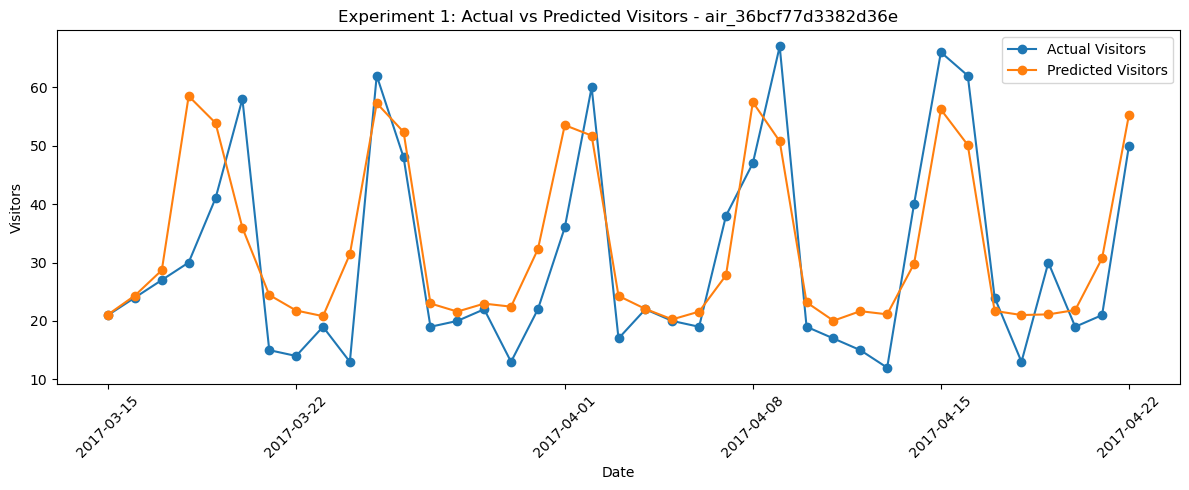

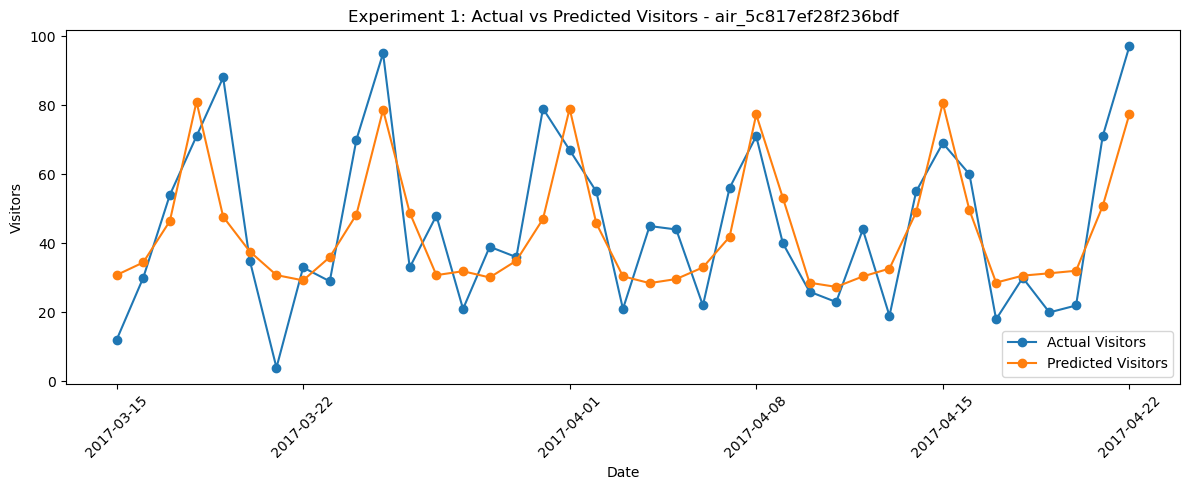

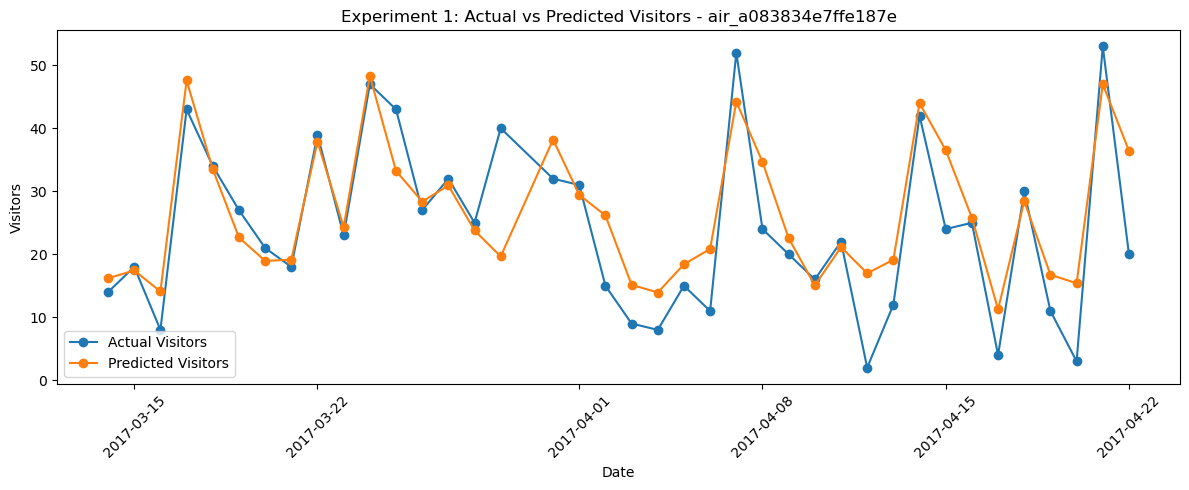

In [9]:
# ------------------------------------------------------------
# 6. Plot actual vs predicted for each restaurant
# ------------------------------------------------------------

for restaurant_id in store_specific_extra_results["air_store_id"].unique():

    temp = store_specific_extra_results[
        store_specific_extra_results["air_store_id"] == restaurant_id
    ].copy()

    plt.figure(figsize=(12, 5))
    plt.plot(
        temp["visit_date"],
        temp["visitors"],
        marker="o",
        label="Actual Visitors"
    )
    plt.plot(
        temp["visit_date"],
        temp["predicted_visitors"],
        marker="o",
        label="Predicted Visitors"
    )

    plt.title(f"Experiment 1: Actual vs Predicted Visitors - {restaurant_id}")
    plt.xlabel("Date")
    plt.ylabel("Visitors")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# ------------------------------------------------------------
# 7. Convert daily predictions into weekly predictions
# ------------------------------------------------------------

daily_predictions = store_specific_extra_results.copy()

daily_predictions["visit_date"] = pd.to_datetime(daily_predictions["visit_date"])

daily_predictions["week_start"] = (
    daily_predictions["visit_date"]
    - pd.to_timedelta(daily_predictions["visit_date"].dt.weekday, unit="D")
)

daily_predictions["week_end"] = daily_predictions["week_start"] + pd.Timedelta(days=6)

weekly_predictions_extra = (
    daily_predictions
    .groupby(["air_store_id", "week_start", "week_end"])
    .agg(
        days_in_week=("visit_date", "count"),
        actual_weekly_visitors=("visitors", "sum"),
        predicted_weekly_visitors=("predicted_visitors", "sum"),
        predicted_weekly_visitors_rounded=("predicted_visitors_rounded", "sum"),
        average_daily_error=("absolute_error", "mean")
    )
    .reset_index()
)

weekly_predictions_extra["weekly_absolute_error"] = abs(
    weekly_predictions_extra["actual_weekly_visitors"]
    - weekly_predictions_extra["predicted_weekly_visitors"]
)

weekly_predictions_extra["weekly_practical_accuracy_percent"] = (
    1 - (
        weekly_predictions_extra["weekly_absolute_error"]
        / weekly_predictions_extra["actual_weekly_visitors"]
    )
) * 100

weekly_predictions_extra

,air_store_id,week_start,week_end,days_in_week,actual_weekly_visitors,predicted_weekly_visitors,predicted_weekly_visitors_rounded,average_daily_error,weekly_absolute_error,weekly_practical_accuracy_percent
0,air_36bcf77d3382d36e,2017-03-13,2017-03-19,5,143,186.514737,186,8.702947,43.514737,69.570114
1,air_36bcf77d3382d36e,2017-03-20,2017-03-26,7,229,244.043078,243,9.797683,15.043078,93.430970
2,air_36bcf77d3382d36e,2017-03-27,2017-04-02,7,192,227.521871,228,7.439204,35.521871,81.499026
3,air_36bcf77d3382d36e,2017-04-03,2017-04-09,7,230,224.207109,224,6.728317,5.792891,97.481352
4,air_36bcf77d3382d36e,2017-04-10,2017-04-16,7,231,222.119144,222,7.846576,8.880856,96.155474
5,air_36bcf77d3382d36e,2017-04-17,2017-04-23,6,157,171.729204,172,6.175998,14.729204,90.618341
6,air_5c817ef28f236bdf,2017-03-13,2017-03-19,5,255,240.383743,240,16.227124,14.616257,94.268134
7,air_5c817ef28f236bdf,2017-03-20,2017-03-26,7,299,309.503710,310,13.432415,10.503710,96.487053
8,air_5c817ef28f236bdf,2017-03-27,2017-04-02,7,345,299.618606,300,13.031591,45.381394,86.845973
9,air_5c817ef28f236bdf,2017-04-03,2017-04-09,7,299,293.896284,293,12.134372,5.103716,98.293071


In [11]:
# ------------------------------------------------------------
# 8. Evaluate only full 7-day weeks
# ------------------------------------------------------------

full_week_extra = weekly_predictions_extra[
    weekly_predictions_extra["days_in_week"] == 7
].copy()

print("Total weekly rows:", len(weekly_predictions_extra))
print("Full 7-day weekly rows:", len(full_week_extra))

if len(full_week_extra) > 0:

    weekly_mae = mean_absolute_error(
        full_week_extra["actual_weekly_visitors"],
        full_week_extra["predicted_weekly_visitors"]
    )

    weekly_rmse = np.sqrt(mean_squared_error(
        full_week_extra["actual_weekly_visitors"],
        full_week_extra["predicted_weekly_visitors"]
    ))

    weekly_r2 = r2_score(
        full_week_extra["actual_weekly_visitors"],
        full_week_extra["predicted_weekly_visitors"]
    )

    weekly_mean_actual = full_week_extra["actual_weekly_visitors"].mean()

    weekly_practical_accuracy = (1 - (weekly_mae / weekly_mean_actual)) * 100

    print("EXPERIMENT 1 FULL-WEEK EVALUATION")
    print("---------------------------------")
    print(f"Full-week MAE: {weekly_mae:.2f} visitors")
    print(f"Full-week RMSE: {weekly_rmse:.2f} visitors")
    print(f"Full-week R² Score: {weekly_r2:.4f}")
    print(f"Mean actual full-week visitors: {weekly_mean_actual:.2f}")
    print(f"Full-week practical accuracy estimate: {weekly_practical_accuracy:.2f}%")

else:
    print("No full 7-day weeks found.")

Total weekly rows: 18
Full 7-day weekly rows: 11
EXPERIMENT 1 FULL-WEEK EVALUATION
---------------------------------
Full-week MAE: 18.42 visitors
Full-week RMSE: 23.51 visitors
Full-week R² Score: 0.8612
Mean actual full-week visitors: 238.27
Full-week practical accuracy estimate: 92.27%


In [12]:
weekly_predictions_extra.to_csv(
    DATA_DIR / "experiment1_store_specific_rf_extra_weekly_results.csv",
    index=False
)

full_week_extra.to_csv(
    DATA_DIR / "experiment1_store_specific_rf_extra_full_week_results.csv",
    index=False
)

print("Experiment 1 weekly results saved.")

Experiment 1 weekly results saved.


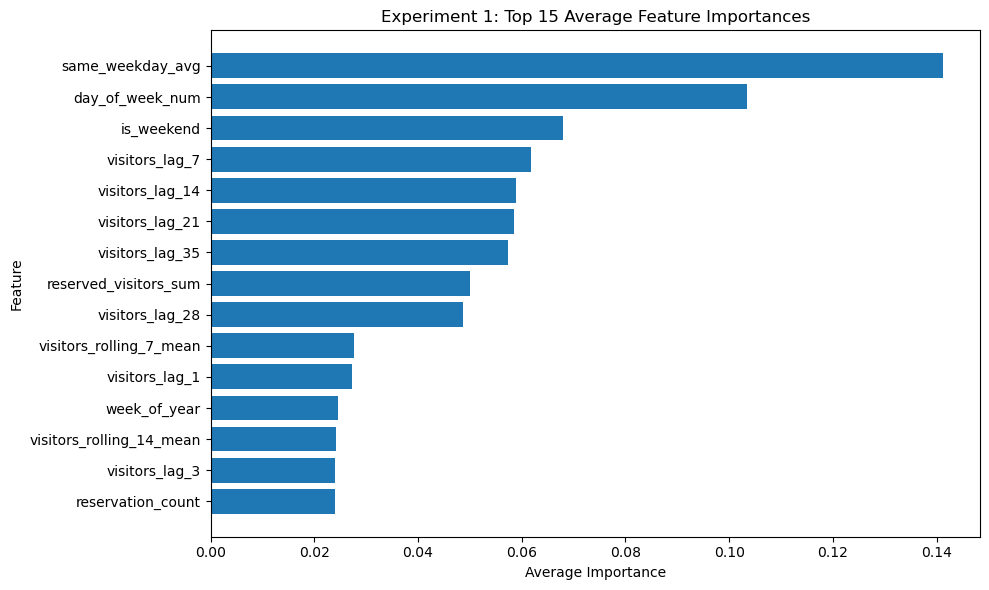

,feature,importance
17,same_weekday_avg,0.141305
7,day_of_week_num,0.103403
10,is_weekend,0.067876
25,visitors_lag_7,0.061759
19,visitors_lag_14,0.058797
21,visitors_lag_21,0.058462
24,visitors_lag_35,0.057389
16,reserved_visitors_sum,0.050071
22,visitors_lag_28,0.048582
30,visitors_rolling_7_mean,0.027632


In [13]:
# ------------------------------------------------------------
# 9. Average feature importance across restaurant-specific models
# ------------------------------------------------------------

average_feature_importance = (
    feature_importance_extra_df
    .groupby("feature")["importance"]
    .mean()
    .reset_index()
    .sort_values(by="importance", ascending=False)
)

top_features = average_feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Experiment 1: Top 15 Average Feature Importances")
plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

average_feature_importance.head(20)